In [0]:
# ===============================
# Import Required Libraries
# ===============================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)

In [0]:
from pyspark.sql.types import *

review_schema = StructType([
    StructField("asin", StringType()),
    StructField("helpful_vote", LongType()),

    StructField(
        "images",
        ArrayType(
            StructType([
                StructField("attachment_type", StringType()),
                StructField("large_image_url", StringType()),
                StructField("medium_image_url", StringType()),
                StructField("small_image_url", StringType())
            ])
        )
    ),

    StructField("parent_asin", StringType()),
    StructField("rating", DoubleType()),
    StructField("text", StringType()),
    StructField("timestamp", LongType()),
    StructField("title", StringType()),
    StructField("user_id", StringType()),
    StructField("verified_purchase", BooleanType())
])

reviews_df = spark.read.schema(review_schema).json(
    "/Volumes/project/default/data/Appliances.jsonl"
)

In [0]:
# ==========================================
# Review Dataset Overview
# ==========================================

print("="*70)
print("Review Dataset Overview")
print("="*70)

print(f"Total Reviews : {reviews_df.count():,}")
print(f"Total Columns : {len(reviews_df.columns)}")

Review Dataset Overview
Total Reviews : 2,128,605
Total Columns : 10


In [0]:
rating_df = (
    reviews_df
    .groupBy("rating")
    .count()
    .orderBy("rating")
)

rating_pd = rating_df.toPandas()

rating_pd

,rating,count
0,1.0,250453
1,2.0,79664
2,3.0,104047
3,4.0,208216
4,5.0,1486225


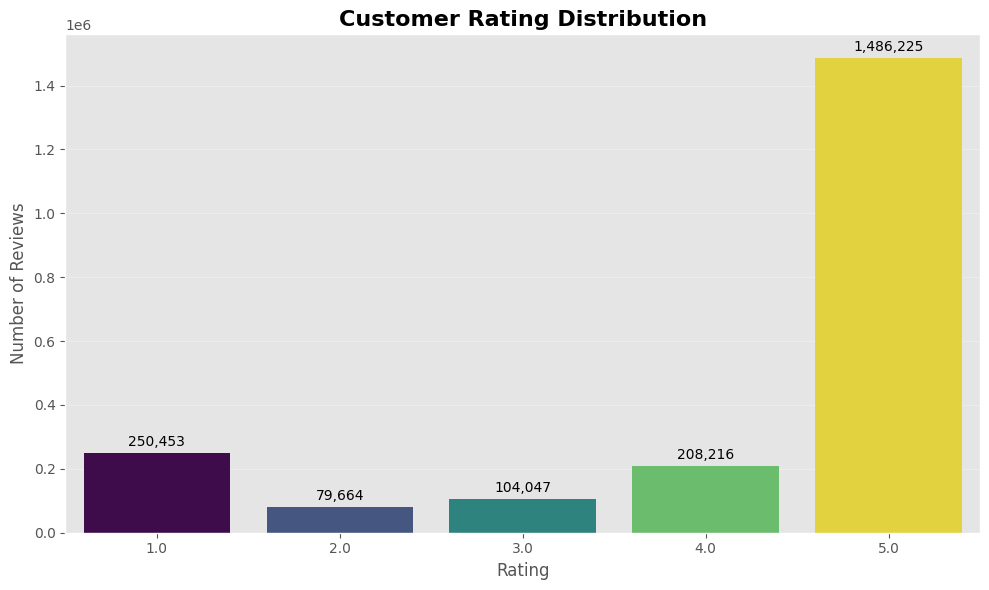

In [0]:
# ==========================================
# Customer Rating Distribution
# ==========================================

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=rating_pd,
    x="rating",
    y="count",
    hue="rating",
    palette="viridis",
    legend=False
)

# Add formatted value labels
for container in ax.containers:
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10
    )

plt.title(
    "Customer Rating Distribution",
    fontsize=16,
    weight="bold"
)

plt.xlabel(
    "Rating",
    fontsize=12
)

plt.ylabel(
    "Number of Reviews",
    fontsize=12
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Verified Purchase Analysis
# ==========================================

verified_df = (
    reviews_df
    .groupBy("verified_purchase")
    .count()
)

verified_pd = verified_df.toPandas()

verified_pd["verified_purchase"] = verified_pd["verified_purchase"].replace({
    True: "Verified Purchase",
    False: "Non-Verified Purchase"
})

verified_pd

,verified_purchase,count
0,Non-Verified Purchase,88541
1,Verified Purchase,2040064


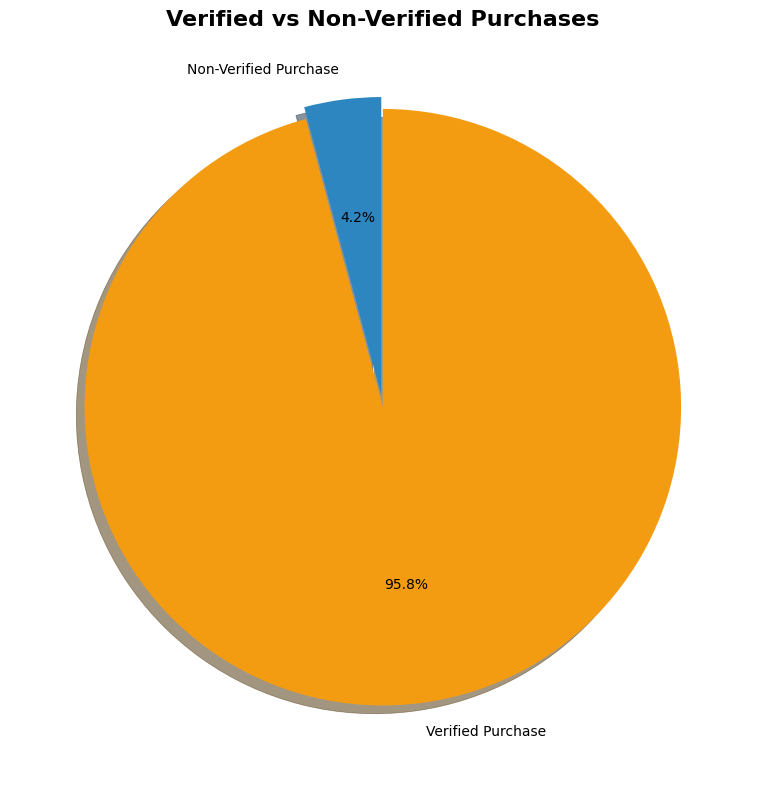

In [0]:
# ==========================================
# Verified Purchase Distribution
# ==========================================

plt.figure(figsize=(8,8))

colors = ["#2E86C1", "#F39C12"]

plt.pie(
    verified_pd["count"],
    labels=verified_pd["verified_purchase"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=(0.04,0),
    shadow=True
)

plt.title(
    "Verified vs Non-Verified Purchases",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Helpful Vote Statistics
# ==========================================

display(
    reviews_df.select("helpful_vote").describe()
)

summary,helpful_vote
count,2128605
mean,0.9288867591685634
stddev,12.526794316769505
min,0
max,5704


In [0]:
# ==========================================
# Prepare Helpful Vote Data
# ==========================================

help_limit = reviews_df.approxQuantile(
    "helpful_vote",
    [0.99],
    0.01
)[0]

help_pd = (
    reviews_df
    .filter(
        (F.col("helpful_vote").isNotNull()) &
        (F.col("helpful_vote") <= help_limit)
    )
    .select("helpful_vote")
    .toPandas()
)

help_pd.head()

,helpful_vote
0,0
1,0
2,0
3,0
4,0


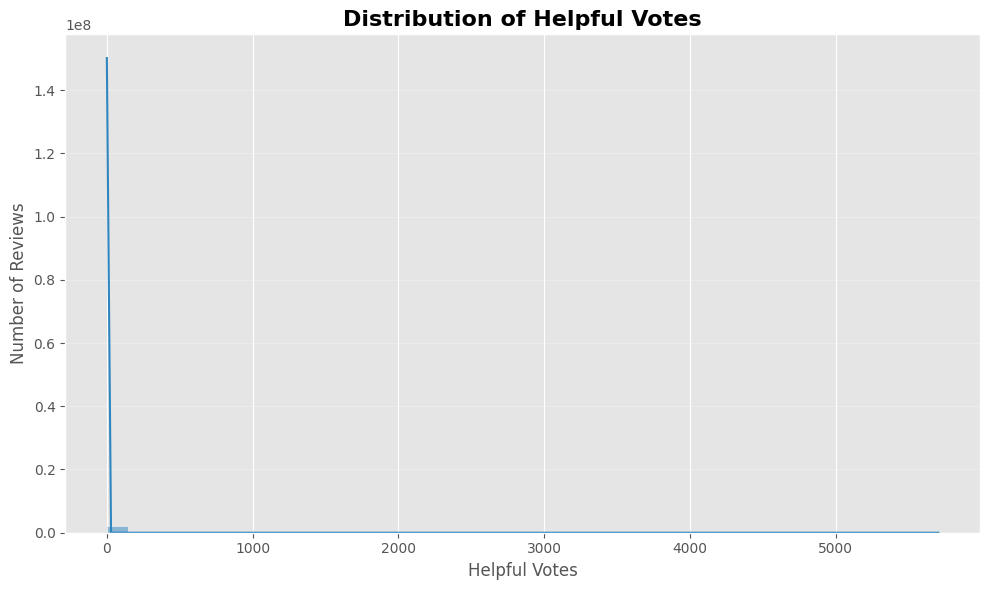

In [0]:
# ==========================================
# Helpful Vote Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=help_pd,
    x="helpful_vote",
    bins=40,
    kde=True,
    color="#2E86C1"
)

plt.title(
    "Distribution of Helpful Votes",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Helpful Votes")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Create Review Length Feature
# ==========================================

reviews_length = reviews_df.withColumn(
    "review_length",
    F.length(F.col("text"))
)

display(
    reviews_length.select("review_length").describe()
)

summary,review_length
count,2128605
mean,169.51345223749826
stddev,279.98141951014395
min,0
max,30004


In [0]:
# ==========================================
# Prepare Review Length Data
# ==========================================

length_limit = reviews_length.approxQuantile(
    "review_length",
    [0.99],
    0.01
)[0]

length_pd = (
    reviews_length
    .filter(F.col("review_length") <= length_limit)
    .select("review_length")
    .toPandas()
)

length_pd.head()

,review_length
0,37
1,23
2,32
3,299
4,51


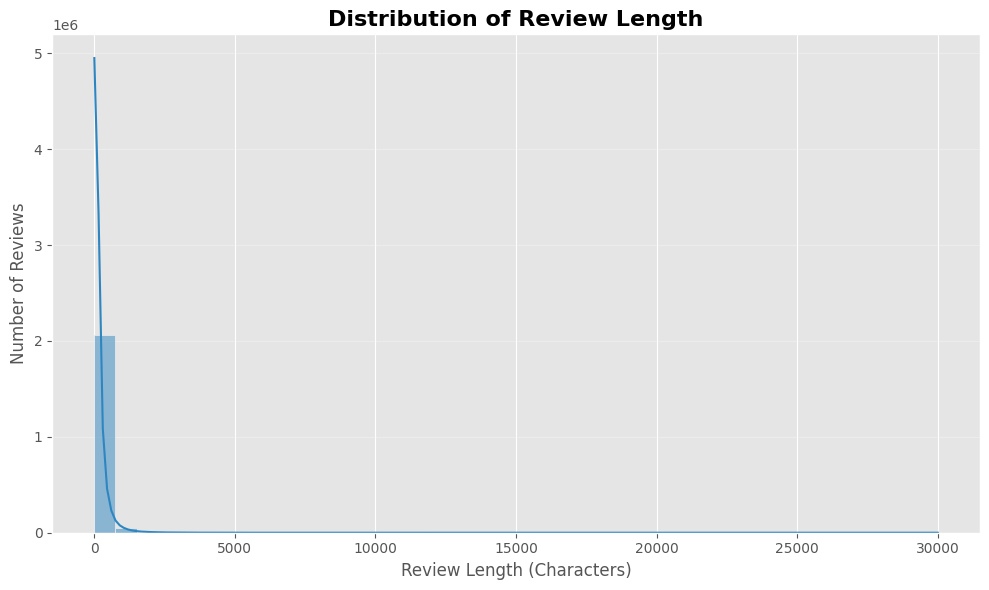

In [0]:
# ==========================================
# Review Length Distribution
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=length_pd,
    x="review_length",
    bins=40,
    kde=True,
    color="#2E86C1"
)

plt.title(
    "Distribution of Review Length",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Review Length (Characters)")
plt.ylabel("Number of Reviews")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Customer Activity Analysis
# ==========================================

customer_activity = (
    reviews_df
    .groupBy("user_id")
    .count()
    .withColumnRenamed("count", "review_count")
)

display(customer_activity.describe())

summary,user_id,review_count
count,1755732,1755732
mean,null,1.2123746676599845
stddev,null,0.6759095425257763
min,AE22236AFRRSMQIKGG7TPTB75QEA,1
max,AHZZZZPE45DYV2WZ2MYXZRHWSEKA,111


In [0]:
# ==========================================
# Top 10 Most Active Reviewers
# ==========================================

top_reviewers = (
    customer_activity
    .orderBy(F.desc("review_count"))
    .limit(10)
)

display(top_reviewers)

user_id,review_count
AHJGIPM2BSL2PQIP2223Y2WVVAPQ,111
AF5NXJDWHE77HSJ4LERATTFVS2LA,66
AHKNU4DNSSZYUFUOBEUBGLF7I7EA,66
AHEYN6GU45YH2SZCFXVVNWAPOJIQ,57
AEUSUUHXIIA5R4Q3WJB53GKACOVQ,50
AEOV4JIKICCCT52K5NT3V32A6Y3Q,48
AGBUVBEWICTFWY26GY6PJ6EWRCUQ,48
AGLKQFJXDPM6U6S7GMQKOYAHHVIA,46
AFQMMW3VP54Q3H7UTYY2UQ4EL7RA,45
AFVNK27OKUAMOI7ZBYRTC4LBRHUQ,43


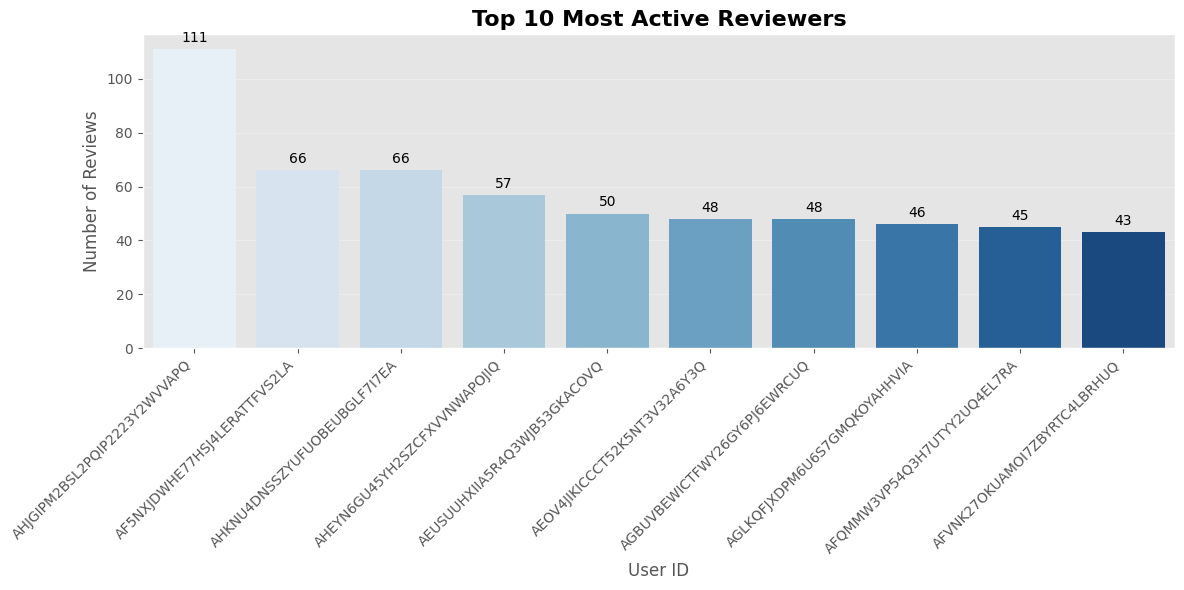

In [0]:
# ==========================================
# Top 10 Most Active Reviewers
# ==========================================

top_reviewers_pd = top_reviewers.toPandas()

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_reviewers_pd,
    x="user_id",
    y="review_count",
    hue="user_id",
    palette="Blues",
    legend=False
)

# Value Labels
for container in ax.containers:
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=10
    )

plt.title(
    "Top 10 Most Active Reviewers",
    fontsize=16,
    weight="bold"
)

plt.xlabel("User ID")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Review Dataset KPI Summary
# ==========================================

verified_reviews = reviews_df.filter(
    F.col("verified_purchase") == True
).count()

total_reviews = reviews_df.count()

avg_rating = reviews_df.select(
    F.avg("rating")
).first()[0]

avg_helpful = reviews_df.select(
    F.avg("helpful_vote")
).first()[0]

avg_review_length = reviews_length.select(
    F.avg("review_length")
).first()[0]

kpi = pd.DataFrame({
    "Metric": [
        "Total Reviews",
        "Verified Purchase %",
        "Average Rating",
        "Average Helpful Votes",
        "Average Review Length"
    ],
    "Value": [
        f"{total_reviews:,}",
        f"{(verified_reviews / total_reviews) * 100:.2f}%",
        f"{avg_rating:.2f}",
        f"{avg_helpful:.2f}",
        f"{avg_review_length:.2f}"
    ]
})

kpi

,Metric,Value
0,Total Reviews,"2,128,605"
1,Verified Purchase %,95.84%
2,Average Rating,4.22
3,Average Helpful Votes,0.93
4,Average Review Length,169.51
